#Introducere în Machine Learning


###Laboratorul 1

 Sarcini practice bazate pe setul de date Iris.csv

- Pandas https://pandas.pydata.org/docs/,
- Matplotlib https://matplotlib.org/,
- Seaborn https://seaborn.pydata.org/,
- Intel Extension for Scikit-learn https://uxlfoundation.github.io/scikit-learn-intelex/latest/index.html

### Exercițiul 1: Încărcarea și analiza inițială a datelor

Folosind bibliotecile pandas și numpy, încărcați fișierul Iris_Data.csv din directorul data. Afișați pe ecran:
 - Numărul total de rânduri.
 - Numele tuturor coloanelor.
 - Tipurile de date pentru fiecare coloană.

**Rezolvare:**

In [ ]:
import os
import numpy as np
import pandas as pd

file_names = ['Iris_Data - Iris_Data.csv']
data_dirs = ['.', 'data']

filepath = None
for d in data_dirs:
    for f in file_names:
        p = os.sep.join([d, f])
        if os.path.exists(p):
            filepath = p
            break
    if filepath:
        break

if filepath is None:
    raise FileNotFoundError("Nu am găsit fișierul CSV. Puneți-l în același folder cu notebook-ul.")

data = pd.read_csv(filepath)
print("Fișier încărcat:", filepath)
data.head()

Fișier încărcat: .\Iris_Data - Iris_Data.csv


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
print("Numărul de rânduri:", data.shape[0])

print("Coloanele:", data.columns.tolist())

print("\nTipurile de date:")
print(data.dtypes)

Numărul de rânduri: 150
Coloanele: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

Tipurile de date:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species             str
dtype: object


###Exercițiul 2: Curățarea și transformarea datelor text

Explorați valorile din coloana species.
Observați că toate încep cu prefixul Iris-.

Scrieți cod pentru a elimina acest prefix din toate rândurile (astfel încât să rămână doar setosa, versicolor, virginica).

**Rezolvare:**

In [ ]:
print(data.species.unique())

<StringArray>
['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
Length: 3, dtype: str


In [ ]:
data['species'] = data.species.str.replace('Iris-', '', regex=False)

print(data.species.unique())
data.head()

<StringArray>
['setosa', 'versicolor', 'virginica']
Length: 3, dtype: str


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### Exercițiul 3: Statistica descriptivă și amplitudinea (range)

Folosind metoda describe()creați un rând nou în tabel numit range, care calculează diferența dintre valoarea maximă și valoarea minimă pentru fiecare coloană numerică.

**Rezolvare:**

In [ ]:
stats_df = data.describe()

stats_df.loc['range'] = stats_df.loc['max'] - stats_df.loc['min']
stats_df

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000
range,3.600000,2.400000,5.900000,2.400000


### Exercițiul 4: Grupatarea datelor pe specii (Media și Mediana)
 Grupați setul de date după coloana species  și aplicați simultan funcțiile de medie (mean)și mediană (median) pentru toate coloanele numerice.

**Rezolvare:**

In [ ]:
data.groupby('species').agg(['mean', 'median'])

sepal_length        sepal_width        petal_length         \
                   mean median        mean median         mean median   
species                                                                 
setosa            5.006    5.0       3.418    3.4        1.464   1.50   
versicolor        5.936    5.9       2.770    2.8        4.260   4.35   
virginica         6.588    6.5       2.974    3.0        5.552   5.55   

           petal_width         
                  mean median  
species                        
setosa           0.244    0.2  
versicolor       1.326    1.3  
virginica        2.026    2.0

### Exercițiul 5: Agregare avansată utilizând un dicționar

Folosind metoda agg() pentru datele grupate
aplicați următoarele reguli: pentru sepal_length, sepal_width și petal_width calculați media și mediana, iar pentru petal_length — doar valoarea maximă (max).

**Rezolvare:**

In [ ]:
from pprint import pprint

agg_dict = {
    'sepal_length': ['mean', 'median'],
    'sepal_width':  ['mean', 'median'],
    'petal_width':  ['mean', 'median'],
    'petal_length': 'max',
}
pprint(agg_dict)

data.groupby('species').agg(agg_dict)

{'petal_length': 'max',
 'petal_width': ['mean', 'median'],
 'sepal_length': ['mean', 'median'],
 'sepal_width': ['mean', 'median']}


sepal_length        sepal_width        petal_width         \
                   mean median        mean median        mean median   
species                                                                
setosa            5.006    5.0       3.418    3.4       0.244    0.2   
versicolor        5.936    5.9       2.770    2.8       1.326    1.3   
virginica         6.588    6.5       2.974    3.0       2.026    2.0   

           petal_length  
                    max  
species                  
setosa              1.9  
versicolor          5.1  
virginica           6.9

### Exercițiul 6: Vizualizarea datelor cu ajutorul Matplotlib

Importați matplotlib.pyplot și construiți un diagramă de dispersie (scatter plot) care reflectă dependența dintre sepal_length (axa X) și sepal_width (axa Y).
   Adăugați etichete pentru axe și un titlu.

**Rezolvare:**

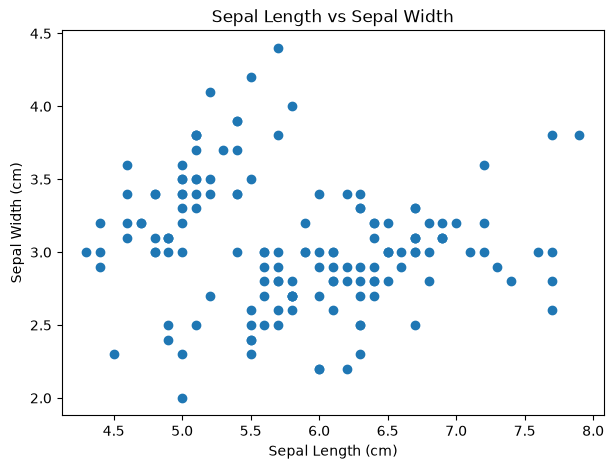

In [9]:
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(data.sepal_length, data.sepal_width)

ax.set(xlabel='Sepal Length (cm)',
       ylabel='Sepal Width (cm)',
       title='Sepal Length vs Sepal Width')
plt.show()

### Exercițiul 7: Numărarea frecvenței speciilor
 Folosiți o metodă specială din Pandas pentru a afla numărul exact de înregistrări pentru fiecare specie în parte din setul de date curățat.

**Rezolvare:**

In [ ]:
data.species.value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

### Exercițiul 8: Accelerarea Scikit-learn folosind Intel® Extension

Scrieți liniile de cod care trebuie executate imediat după importarea bibliotecii sklearn pentru a activa optimizarea oneDAL

**Rezolvare:**

Liniile se execută imediat după importul `sklearn` (în Colab, instalați mai întâi pachetul: `!pip install scikit-learn-intelex`).

In [ ]:
import sklearn

try:
    from sklearnex import patch_sklearn
    patch_sklearn()
except ImportError:
    print("scikit-learn-intelex nu este instalat; rulați: pip install scikit-learn-intelex")

Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


### Exercițiul 9: Framework-uri în Machine Learning\

Bazându-vă pe materialele introductive, explicați de ce framework-urile sunt mai mult decât simple biblioteci și ce beneficiu material aduce optimizarea hiperparametrilor.

**Răspuns:**

**Framework-urile sunt mai mult decât simple biblioteci** deoarece o bibliotecă oferă doar cod apelabil (funcții și clase pe care le folosim când avem nevoie), în timp ce un framework oferă și *structura* după care oamenii de știință a datelor (Data Scientists) își scriu codul: influențează modul în care este organizat și scris programul, nu doar ce funcții apelăm. Scikit-learn este un astfel de framework, cu un mod unitar de lucru (`fit`, `predict`, `score`) pentru toți algoritmii.

**Beneficiul material al optimizării hiperparametrilor:** un framework optimizat (de exemplu scikit-learn cu extensia Intel® / oneDAL) rulează codul mai repede, ceea ce este convenabil, dar avantajul real apare în știința datelor aplicată și în modelele de IA. Rularea mai rapidă permite testarea multor combinații de hiperparametri în același timp, iar optimizarea lor duce la modele mai precise și mai bune, deci beneficii care depășesc simpla viteză (calitate mai bună a modelului, mai puține resurse de calcul consumate).

### Exercițiul 10: Cerințe preliminare ale cursului
  Enumerați cel puțin trei direcții de bază  (în matematică și programare) necesare pentru parcurgerea cu succes a cursului de Machine Learning

**Răspuns:** direcțiile de bază necesare pentru cursul de Machine Learning sunt:

1. **Programare în Python** (inclusiv biblioteci precum NumPy, Pandas, Matplotlib).
2. **Calcul diferențial și integral (Calculus)**: derivate și gradienți, folosiți la optimizarea modelelor.
3. **Algebră liniară**: vectori, matrici, operații matriceale, folosite la reprezentarea datelor și a modelelor.
4. **Statistică** (și teoria probabilităților): distribuții, medie, mediană, corelație, pentru analiza și interpretarea datelor.

### Exercițiul 11: Vizualizarea avansată a distribuțiilor cu Matplotlib (Histograme)
 Folosind Matplotlib, construiți o figură cu două subgrafice (subplots) alături unul de celălalt (1 rând, 2 coloane):
 - Pe primul grafic afișați histogramei de distribuție pentru petal_length.
 - Pe al doilea grafic afișați histogramei de distribuție pentru petal_width.

 Adăugați titluri și etichete la axe pentru fiecare grafic.

**Rezolvare:**

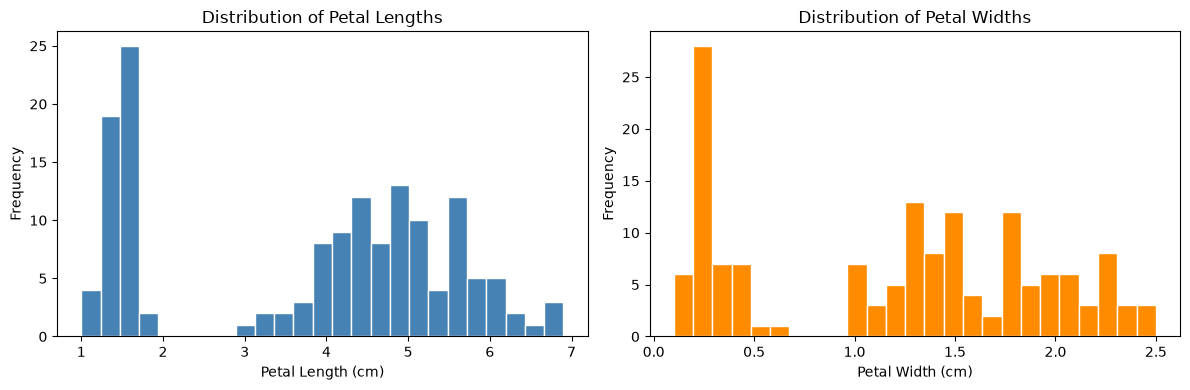

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(data.petal_length, bins=25, color='steelblue', edgecolor='white')
axes[0].set(xlabel='Petal Length (cm)',
            ylabel='Frequency',
            title='Distribution of Petal Lengths')

axes[1].hist(data.petal_width, bins=25, color='darkorange', edgecolor='white')
axes[1].set(xlabel='Petal Width (cm)',
            ylabel='Frequency',
            title='Distribution of Petal Widths')

plt.tight_layout()
plt.show()

### Exercițiul 12: Explorarea datelor cu ajutorul Seaborn (Pairplot)

Importați biblioteca seaborn și construiți o matrice de grafice perechi (sns.pairplot)  pentru întregul set de date Iris, colorând punctele în funcție de specia plantei (species).

**Rezolvare:**

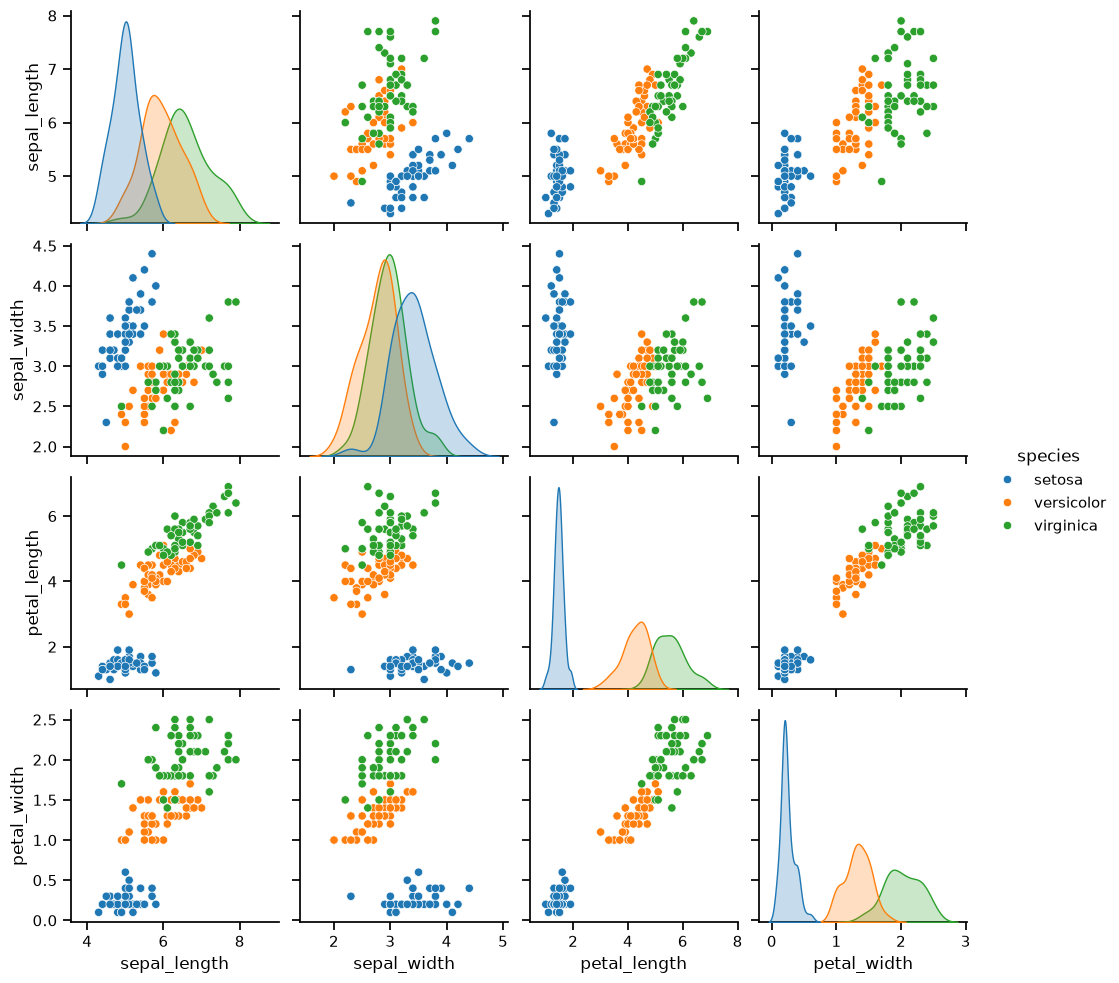

In [13]:
import seaborn as sns

sns.set_context('notebook')
sns.pairplot(data, hue='species')
plt.show()

### Exercițiul 13: Analiza valorilor aberante prin Boxplot (Seaborn)

Folosind biblioteca Seaborn, construiți un diagramă box-and-whisker (sns.boxplot), pentru a compara distribuția lungimii petalelor (petal_length) pentru fiecare specie în parte (species).

**Rezolvare:**

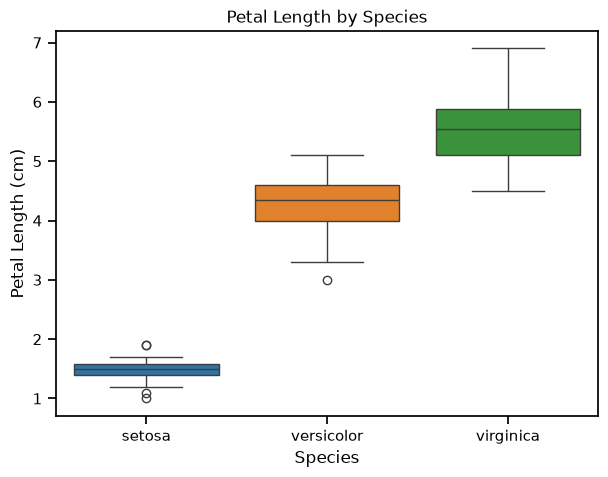

In [14]:
plt.figure(figsize=(7, 5))
sns.boxplot(x='species', y='petal_length', hue='species', data=data)

plt.xlabel('Species')
plt.ylabel('Petal Length (cm)')
plt.title('Petal Length by Species')
plt.show()

### Exercițiul 14: Harta termică a corelațiilor (Seaborn Heatmap)
 Calculați matricea de corelație a caracteristicilor numerice folosind metoda corr(), iar apoi vizualizați-o sub formă de hartă termică (sns.heatmap), incluzând afișarea valorilor numerice în interiorul celulelor (annot=True).

**Rezolvare:**

In [ ]:
corr = data.corr(numeric_only=True)
corr

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.109369,0.871754,0.817954
sepal_width,-0.109369,1.000000,-0.420516,-0.356544
petal_length,0.871754,-0.420516,1.000000,0.962757
petal_width,0.817954,-0.356544,0.962757,1.000000


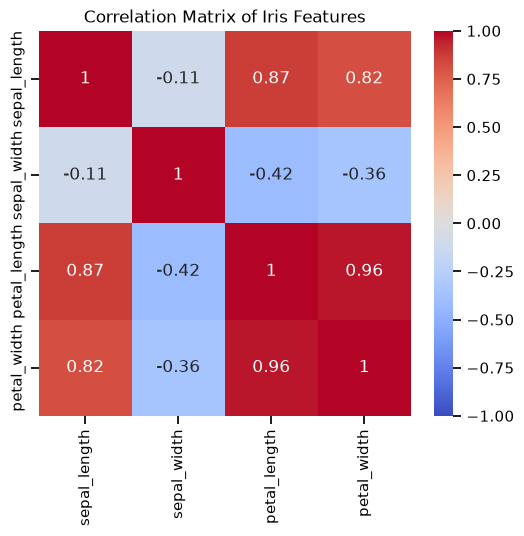

In [16]:
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Iris Features')
plt.show()